In [1]:
import matplotlib.pyplot as plt

In [2]:
!pip -q install diffusers transformers accelerate safetensors

In [3]:
import torch

from diffusers import StableDiffusionXLPipeline
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [5]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to(device)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [6]:
prompt = input("Enter your prompt: ")

print("\nChoose a style:")
print("1. Realistic")
print("2. Anime")
print("3. Oil Painting")
print("4. Watercolor")
print("5. Pixel Art")

choice = input("Enter your choice (1-5): ")

styles = {
    "1": "realistic, ultra detailed, 8k",
    "2": "anime style, vibrant colors",
    "3": "oil painting, masterpiece",
    "4": "watercolor painting",
    "5": "pixel art"
}

style = styles.get(choice, "")

negative_prompt = input("Enter negative prompt (optional): ")

num_images = int(input("How many images do you want (1-4)? "))

final_prompt = prompt + ", " + style

images = pipe(
    prompt=final_prompt,
    negative_prompt=negative_prompt,
    num_images_per_prompt=num_images
).images

Enter your prompt: a bird flying

Choose a style:
1. Realistic
2. Anime
3. Oil Painting
4. Watercolor
5. Pixel Art
Enter your choice (1-5): 1
Enter negative prompt (optional): 2
How many images do you want (1-4)? 4


  0%|          | 0/50 [00:00<?, ?it/s]

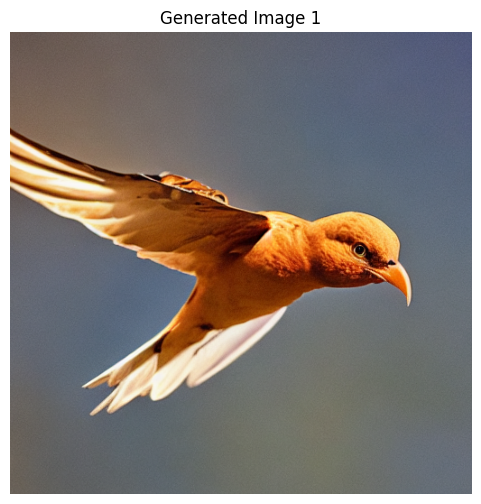

Image 1 saved successfully!


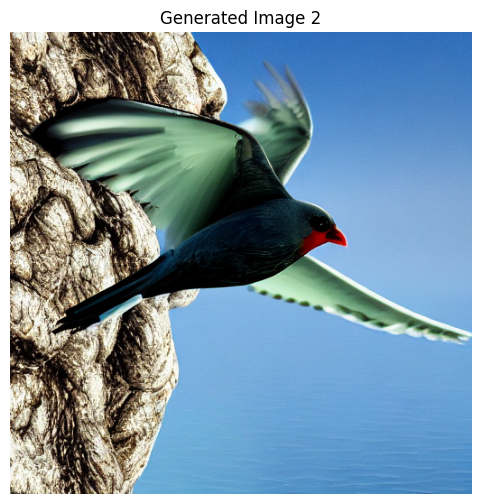

Image 2 saved successfully!


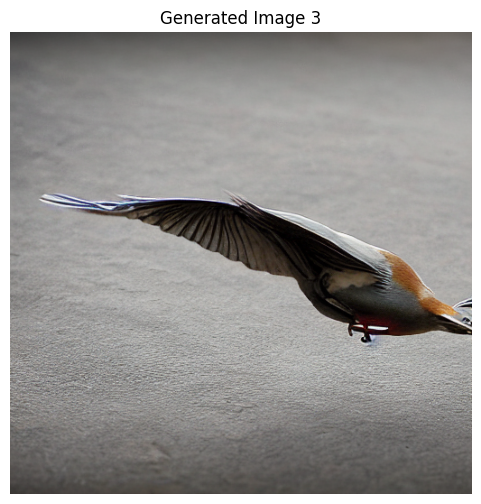

Image 3 saved successfully!


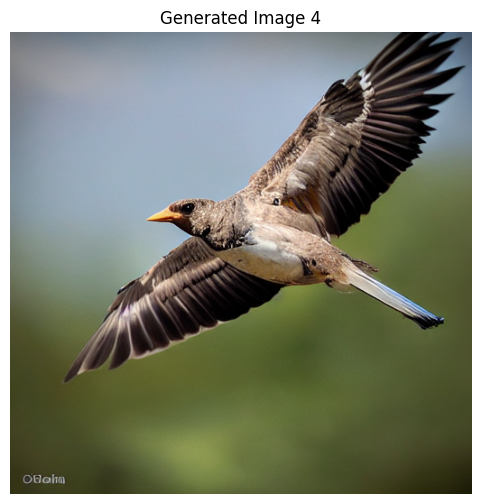

Image 4 saved successfully!


In [7]:
for i, img in enumerate(images):
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Generated Image {i+1}")
    plt.show()

    img.save(f"generated_image_{i+1}.png")
    print(f"Image {i+1} saved successfully!")

In [8]:
!pip install -q gradio

In [9]:
import gradio as gr

In [10]:
import zipfile
import os

styles = {
    "Realistic": "realistic, ultra detailed, 8k",
    "Anime": "anime style, vibrant colors",
    "Oil Painting": "oil painting, masterpiece",
    "Watercolor": "watercolor painting",
    "Pixel Art": "pixel art"
}

def generate_images(prompt, style, negative_prompt, num_images):

    final_prompt = prompt + ", " + styles[style]

    images = pipe(
        prompt=final_prompt,
        negative_prompt=negative_prompt,
        num_images_per_prompt=int(num_images)
    ).images

    # Save generated images
    image_files = []

    for i, img in enumerate(images):
        filename = f"generated_image_{i+1}.png"
        img.save(filename)
        image_files.append(filename)

    # Create ZIP file
    zip_filename = "generated_images.zip"

    with zipfile.ZipFile(zip_filename, "w") as zipf:
        for file in image_files:
            zipf.write(file)

    return images, zip_filename

In [11]:
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("# 🎨 AI Image Generator")

    with gr.Row():

        with gr.Column():

            prompt = gr.Textbox(label="Prompt")

            style = gr.Dropdown(
                choices=["Realistic","Anime","Oil Painting","Watercolor","Pixel Art"]
            )

            negative_prompt = gr.Textbox(label="Negative Prompt")

            num_images = gr.Slider(1,4,value=1)

            generate_btn = gr.Button("Generate Images")

        with gr.Column():

            gallery = gr.Gallery()

            download = gr.File()

    # 👇 THIS MUST BE INSIDE THE BLOCK
    generate_btn.click(
        fn=generate_images,
        inputs=[
            prompt,
            style,
            negative_prompt,
            num_images
        ],
        outputs=[
            gallery,
            download
        ]
    )

demo.launch()

/tmp/ipykernel_1533/3464966072.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://27ce1040157f8e41a1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
